In [21]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#read csv file from the path
df = pd.read_csv(r"C:\Users\cptsp\Downloads\archive\DataScientist.csv")

In [5]:
print(df.info)

<bound method DataFrame.info of       Unnamed: 0  index                                          Job Title  \
0              0      0                              Senior Data Scientist   
1              1      1                  Data Scientist, Product Analytics   
2              2      2                               Data Science Manager   
3              3      3                                       Data Analyst   
4              4      4                             Director, Data Science   
...          ...    ...                                                ...   
3904        3904   4375                                  AWS Data Engineer   
3905        3905   4376                              Data Analyst â Junior   
3906        3906   4377                   Security Analytics Data Engineer   
3907        3907   4378                   Security Analytics Data Engineer   
3908        3908   4379  Patient Safety Physician or Safety Scientist -...   

                   Salary Estim

In [7]:
#find title of the columns
print(df.columns.tolist())

['Unnamed: 0', 'index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply']


In [9]:
#Check for Missing Values
df.isnull().sum()

Unnamed: 0           0
index                0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [11]:
# Checking for duplicate row
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3904    False
3905    False
3906    False
3907    False
3908    False
Length: 3909, dtype: bool

In [13]:
# Show all the duplicate row
df[df.duplicated(keep=False)]

,Unnamed: 0,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply


In [15]:
# drop columns
df = df.drop(columns=['Unnamed: 0', 'index'])

In [17]:
# drop columns
df = df.drop(columns=['Job Description', 'Company Name']) 

In [19]:
#find title of the columns
print(df.columns.tolist())

['Job Title', 'Salary Estimate', 'Rating', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'Easy Apply']


In [41]:
# Checking numbers of value
df['Industry'].value_counts().head(10)

Industry
-1                                         546
IT Services                                472
Staffing & Outsourcing                     313
Biotech & Pharmaceuticals                  293
Computer Hardware & Software               264
Internet                                   238
Health Care Services & Hospitals           197
Consulting                                 166
Enterprise Software & Network Solutions    150
Investment Banking & Asset Management      109
Name: count, dtype: int64

In [61]:
# Checking Column data type
df['Industry'].dtype

dtype('O')

In [63]:
# Changing column to string
df['Industry'] = df['Industry'].astype(str)

In [65]:
# replace -1 with nan
df['Industry'] = df['Industry'].replace('-1', np.nan)

In [67]:
# fill empty with Unknown
df['Industry'] = df['Industry'].fillna('Unknown')

In [69]:
# Checking 
df['Industry'].value_counts().head(10)

Industry
Unknown                                    546
IT Services                                472
Staffing & Outsourcing                     313
Biotech & Pharmaceuticals                  293
Computer Hardware & Software               264
Internet                                   238
Health Care Services & Hospitals           197
Consulting                                 166
Enterprise Software & Network Solutions    150
Investment Banking & Asset Management      109
Name: count, dtype: int64

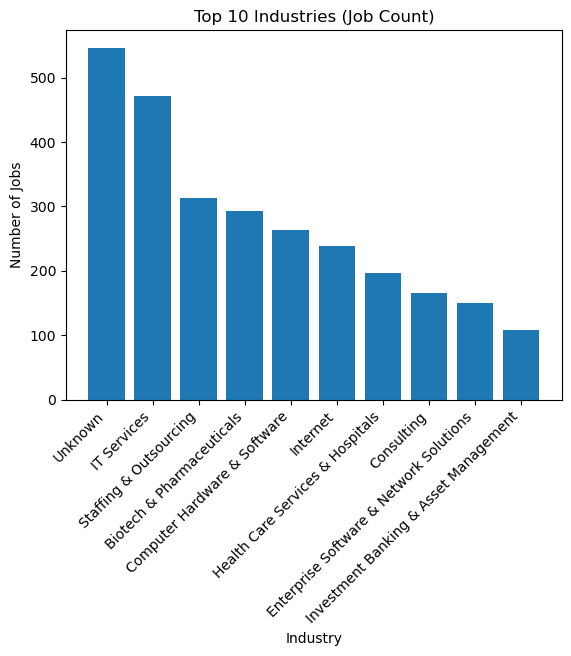

In [71]:

industry_counts = df['Industry'].value_counts().head(10)

plt.bar(industry_counts.index, industry_counts.values)
plt.title("Top 10 Industries (Job Count)")
plt.xlabel("Industry")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45, ha='right')
plt.show()



In [77]:
# Unique value of Salary
df['Salary Estimate'].unique()[:10]

array(['$111-$181 (Glassdoor est.)', '$120-$140 (Glassdoor est.)',
       '$119-$147 (Glassdoor est.)', '$74-$124 (Glassdoor est.)',
       '$102-$121 (Glassdoor est.)', '$129-$210 (Glassdoor est.)',
       '$156-$254 (Glassdoor est.)', '$116-$152 (Glassdoor est.)',
       '$133-$171 (Glassdoor est.)', '$110-$139 (Glassdoor est.)'],
      dtype=object)

In [79]:
import re
df['Salary Estimate'] = df['Salary Estimate'].astype(str)

df['Salary Estimate'] = df['Salary Estimate'].apply(
    lambda x: re.sub(r'[^0-9\-]', '', x)
)

In [81]:
# Finding average salary
df[['min_salary', 'max_salary']] = df['Salary Estimate'].str.split('-', expand=True)

df['min_salary'] = pd.to_numeric(df['min_salary'], errors='coerce')
df['max_salary'] = pd.to_numeric(df['max_salary'], errors='coerce')

df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

In [83]:
df['Salary Estimate'].unique()[:10]

array(['111-181', '120-140', '119-147', '74-124', '102-121', '129-210',
       '156-254', '116-152', '133-171', '110-139'], dtype=object)

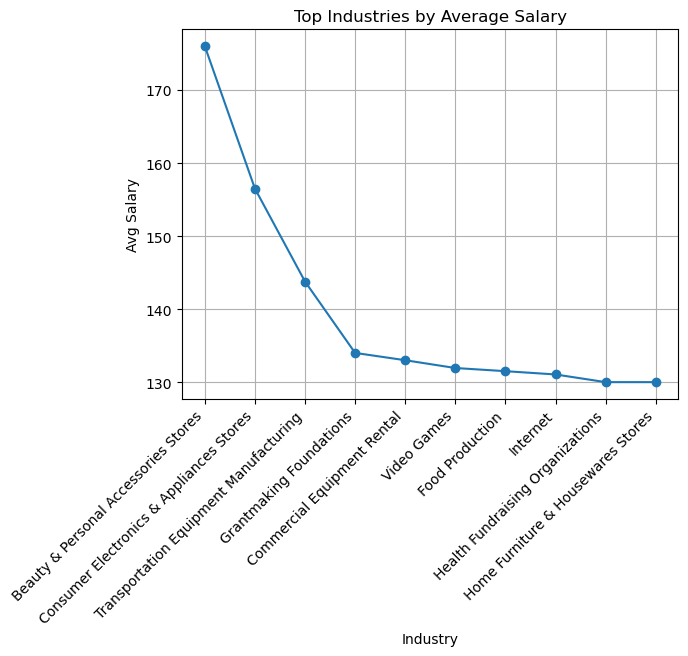

In [118]:
import matplotlib.pyplot as plt

industry_salary = df.groupby('Industry')['avg_salary'].mean().sort_values(ascending=False).head(10)

plt.plot(industry_salary.index, industry_salary.values, marker='o')
plt.title("Top Industries by Average Salary")
plt.xlabel("Industry")
plt.ylabel("Avg Salary")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

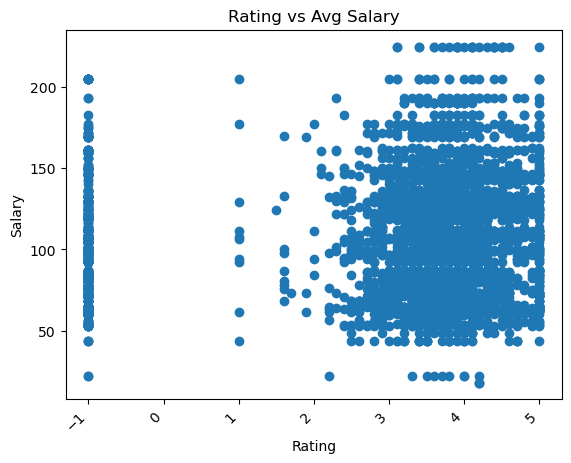

In [123]:
plt.scatter(df['Rating'], df['avg_salary'])
plt.title("Rating vs Avg Salary")
plt.xlabel("Rating")
plt.ylabel("Salary")
plt.xticks(rotation=45, ha='right')
plt.show()

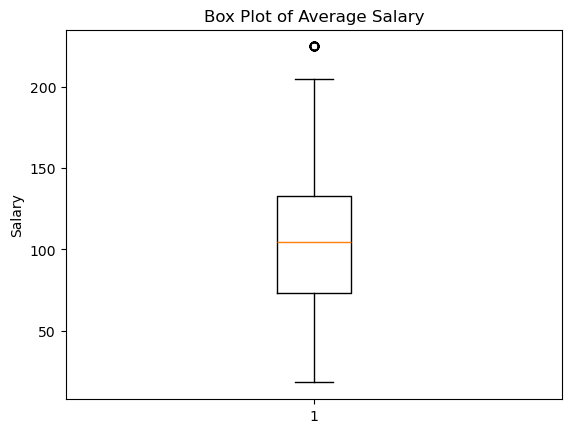

In [105]:
plt.boxplot(df['avg_salary'].dropna())
plt.title("Box Plot of Average Salary")
plt.ylabel("Salary")
plt.show()

In [107]:
# Detect outliner
Q1 = df['avg_salary'].quantile(0.25)
Q3 = df['avg_salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['avg_salary'] < lower_bound) | (df['avg_salary'] > upper_bound)]
outliers 

,Job Title,Salary Estimate,Rating,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,min_salary,max_salary,avg_salary
2980,Diagnostic Research Scientist,200-250,3.9,"San Jose, CA","Seattle, WA",10000+ employees,1994,Company - Public,Internet,Information Technology,$10+ billion (USD),"Google, Microsoft, Walmart",-1,200,250,225.0
2981,Data Analyst,200-250,5.0,"San Jose, CA","Woodridge, IL",51 to 200 employees,2008,Company - Private,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,200,250,225.0
2982,Senior HR Data Analyst,200-250,4.6,"Santa Clara, CA","Santa Clara, CA",10000+ employees,1993,Company - Public,Computer Hardware & Software,Information Technology,$5 to $10 billion (USD),-1,-1,200,250,225.0
2983,"Machine Learning Engineer, TikTok Ads Integrity",200-250,3.8,"Mountain View, CA","Los Angeles, CA",1001 to 5000 employees,2016,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,-1,-1,200,250,225.0
2984,Data Analyst,200-250,4.1,"San Jose, CA","Santa Clara, CA",201 to 500 employees,-1,Company - Private,Unknown,-1,$10 to $25 million (USD),-1,-1,200,250,225.0
2985,Quantum Data Scientist (Industrial-Process sec...,200-250,3.7,"San Jose, CA","Armonk, NY",10000+ employees,1911,Company - Public,IT Services,Information Technology,$10+ billion (USD),"Amazon, Accenture, Microsoft",-1,200,250,225.0
2986,Staff Data Engineer,200-250,3.4,"Santa Clara, CA","Sunnyvale, CA",1001 to 5000 employees,1986,Company - Private,Investment Banking & Asset Management,Finance,Unknown / Non-Applicable,-1,-1,200,250,225.0
2987,Senior Data Scientist,200-250,3.9,"San Jose, CA","San Jose, CA",10000+ employees,1998,Company - Public,Internet,Information Technology,$10+ billion (USD),"Square, Amazon, Apple",-1,200,250,225.0
2988,"Marketing Data Scientist, gTech Professional S...",200-250,4.4,"Mountain View, CA","Mountain View, CA",10000+ employees,1998,Company - Public,Internet,Information Technology,$10+ billion (USD),"Microsoft, Apple, Facebook",-1,200,250,225.0
2989,"Data Scientist, Ad Platforms/Data Insights",200-250,4.1,"Santa Clara, CA","Cupertino, CA",10000+ employees,1976,Company - Public,Computer Hardware & Software,Information Technology,$10+ billion (USD),"Google, Microsoft, Samsung Electronics",-1,200,250,225.0


In [109]:
# Treating Outliner
df_clean = df[(df['avg_salary'] >= lower_bound) & (df['avg_salary'] <= upper_bound)]

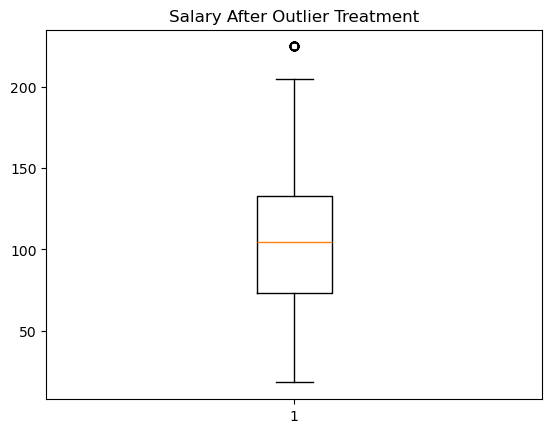

In [111]:
plt.boxplot(df['avg_salary'].dropna())
plt.title("Salary After Outlier Treatment")
plt.show()

In [125]:
# Created new columns
df[['min_salary', 'max_salary', 'avg_salary']].head()

,min_salary,max_salary,avg_salary
0,111,181,146.0
1,111,181,146.0
2,111,181,146.0
3,111,181,146.0
4,111,181,146.0


In [127]:
df[['min_salary', 'max_salary', 'avg_salary']].count()

min_salary    3909
max_salary    3909
avg_salary    3909
dtype: int64

In [129]:
print(df.info)

<bound method DataFrame.info of                                               Job Title Salary Estimate  \
0                                 Senior Data Scientist         111-181   
1                     Data Scientist, Product Analytics         111-181   
2                                  Data Science Manager         111-181   
3                                          Data Analyst         111-181   
4                                Director, Data Science         111-181   
...                                                 ...             ...   
3904                                  AWS Data Engineer          55-112   
3905                              Data Analyst â Junior          55-112   
3906                   Security Analytics Data Engineer          55-112   
3907                   Security Analytics Data Engineer          55-112   
3908  Patient Safety Physician or Safety Scientist -...          55-112   

      Rating       Location      Headquarters                     S